In [1]:
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
path = "./Dataset"
target_size = (224, 224)

In [2]:
insect_classes = ["Butterfly", "Dragonfly", "Grasshopper", "Ladybird", "Mosquito"]
dataset = []
labels = []
name = []
for insect_class in insect_classes:
    class_path = Path(path) / insect_class
    for img_path in class_path.glob("*.jpg"):
        img = Image.open(img_path).convert("RGB")   
        img = img.resize(target_size)
        dataset.append(np.array(img))
        labels.append(insect_class)
        name.append(img_path.name)
dataset = np.array(dataset)
labels = np.array(labels)
name = np.array(name)

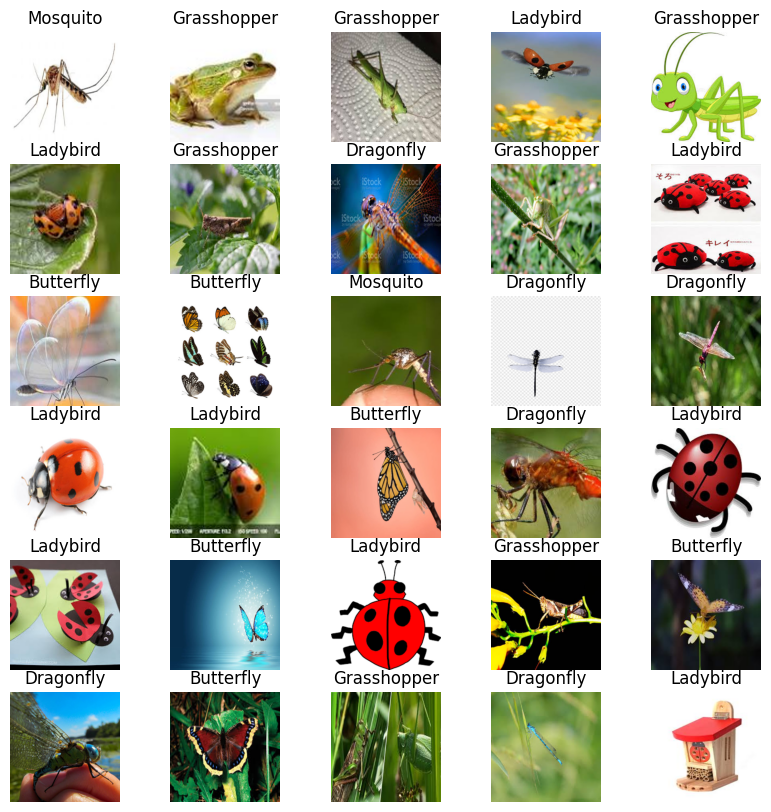

In [17]:

axs = plt.figure(figsize=(10, 10)).subplots(6, 5)
axs = axs.flatten()
for i in range(30):
    n = np.random.randint(0, len(dataset))
    axs[i].imshow(dataset[n])
    axs[i].set_title(labels[n])
    axs[i].axis("off")


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, name_train, name_test = train_test_split(
    dataset, labels, name, test_size=0.2, random_state=42
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape, name_train.shape, name_test.shape

In [4]:
import torch
import cv2
import numpy as np
import requests
from PIL import Image
from torchvision import models, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [5]:
# 3. Image Preprocessing Pipeline
def preprocess_image(img):
    rgb_img = np.float32(img) / 255
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Create input tensor and ensure it's resized for the overlay later
    input_tensor = transform(img).unsqueeze(0)
    rgb_img_resized = cv2.resize(rgb_img, (224, 224))
    return input_tensor, rgb_img_resized

# 4. Run Grad-CAM
# Replace 'your_image.jpg' with your local file path
input_tensor, rgb_img = preprocess_image(dataset[0])  # Using the first image from the dataset for demonstration

In [ ]:
print(dataset.shape)
print(X_train.shape)
print(X_test.shape)
print(input_tensor.shape)
print(rgb_img.shape)

RESNET152

In [18]:
def resnet152_gradcam(input_tensor, rgb_img, threshold=0.5):
    # 1. Load a pre-trained ResNet-152 model
    model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
    model.eval()

    # 2. Target the last convolutional layer
    # For ResNet-152, this is the very last bottleneck block
    target_layers = [model.layer4[-1]]

    # Gradient-weighted Class Activation Mapping (Grad-CAM) is a technique used to visualize the regions of an input
    # image that are most important for a convolutional neural network's (CNN) decision-making process.
    cam = GradCAM(model=model, target_layers=target_layers)

    # If targets=None, it will show the CAM for the highest scoring category
    # The output is a grayscale heatmap of shape [1, 224, 224] that can be overlaid on the original image
    # and values are in the range [0, 1] where higher values indicate more important regions for the model's prediction.
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)  # You can specify a target class index if desired
    mask = np.where(grayscale_cam > threshold, 1, 0)[0]  # Thresholding the CAM for better visualization
    # 5. Overlay and Save
    # We take [0, :] because we only passed one image (batch size 1)
    visualization = show_cam_on_image(rgb_img, grayscale_cam[0, :], use_rgb=True)
    heatmap = cv2.applyColorMap(np.uint8(255 * grayscale_cam[0, :]), cv2.COLORMAP_JET)
    # cam_resnet = visualization
    return heatmap[:,:,::-1], visualization, mask
# plt.imshow(visualization)
# plt.show()
# plt.imshow(rgb_img * mask.reshape(224, 224,1))  # Apply the mask to the original image

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

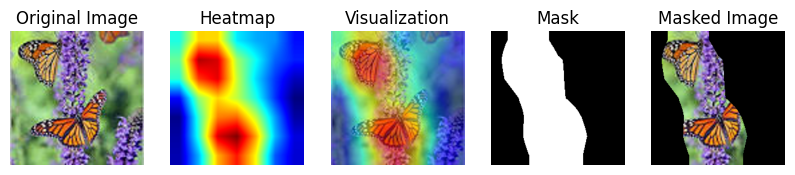

In [44]:
tensor, rgb_img = preprocess_image(dataset[1])  # Using the first image from the dataset for demonstration
heatmap1, visualization1, mask1 = resnet152_gradcam(tensor, rgb_img, threshold=0.5)
axs = plt.figure(figsize=(10, 10)).subplots(1, 5)
axs = axs.flatten()
axs[0].imshow(rgb_img)
axs[0].set_title("Original Image")
axs[0].axis("off")
axs[1].imshow(heatmap1)
axs[1].set_title("Heatmap")
axs[1].axis("off")
axs[2].imshow(visualization1)
axs[2].set_title("Visualization")
axs[2].axis("off")
axs[3].imshow(mask1, cmap="gray")
axs[3].set_title("Mask")
axs[3].axis("off")
axs[4].imshow(rgb_img * mask1.reshape(224, 224,1))  # Apply the mask to the original image
axs[4].set_title("Masked Image")
axs[4].axis("off")



In [6]:
class GrayscaleCAMItem:
    def __init__(self, grayscale_cam, name, label, original_img=None):
        self.grayscale_cam = np.asarray(grayscale_cam)
        self.name = name
        self.label = label
        self.original_img = original_img  # Store the original image, if provided

    def to_heatmap(self):
        return cv2.applyColorMap(np.uint8(255 * self.grayscale_cam), cv2.COLORMAP_JET)[:,:,::-1]

    def to_mask(self, threshold=0.5):
        return np.where(self.grayscale_cam > threshold, 1, 0)
    
    def to_overlay(self):
        if self.original_img is None:
            raise ValueError("Original image must be provided for overlay.")
        overlay = show_cam_on_image(self.original_img, self.grayscale_cam, use_rgb=True)
        return overlay
    
    def to_applied_mask(self, threshold=0.5):
        if self.original_img is None:
            raise ValueError("Original image must be provided for applied mask.")
        mask = self.to_mask(threshold)
        applied_mask = self.original_img * mask.reshape(224, 224, 1)
        return applied_mask

In [7]:
def resnet(images, labels, name, path):
    model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
    model.eval()
    target_layers = [model.layer4[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)
    for i in range(images.shape[0]):
        input_tensor, _ = preprocess_image(images[i])
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
        cam_item = GrayscaleCAMItem(grayscale_cam, name[i], labels[i])
        save_dir = Path(path)
        save_dir.mkdir(parents=True, exist_ok=True)
        np.save(save_dir / f"{i}", cam_item)
        if i % 100 == 0:
            print(f"Processed {i}/{images.shape[0]} images")   

In [ ]:
resnet(X_train[:20], y_train[:20], name_train[:20], path="./Heatmap_train/resnet")

In [8]:
#---------- LONG EXECUTION -----------------
def long_execution1():
    resnet(X_train, y_train, name_train, path="./Heatmap_train/resnet")
    resnet(X_test, y_test, name_test, path="./Heatmap_test/resnet")

In [ ]:
# Load saved grayscale CAMs from ./Heatmap/resnet/Butterfly (fallback to lowercase)
load_dir = Path("./Heatmap_test/resnet") / "Butterfly"
if not load_dir.exists():
    load_dir = Path("./Heatmap_test/resnet") / "butterfly"

npy_files = sorted(load_dir.glob("*.npy"))
cams = {p.stem: np.load(p) for p in npy_files}

print(f"Loaded {len(cams)} CAMs from: {load_dir}")
for name, cam in list(cams.items())[:10]:
    print(name, cam.shape)

# Example: visualize the first loaded CAM (handle possible [1,H,W] shape)
if cams:
    first_key = next(iter(cams))
    cam = cams[first_key]
    # if cam.ndim == 3 and cam.shape[0] == 1:
    #     cam = cam[0]
    plt.figure(figsize=(6,6))
    plt.imshow(cam, cmap='jet')
    plt.title(first_key)
    plt.axis('off')

Vision Transformer

In [22]:
# 1. Define the Reshape Transform for ViT
def vit_reshape_transform(tensor, height=14, width=14):
    # The input 'tensor' has shape [Batch, Num_Tokens, Embedding_Dim]
    # For ViT-B/16, it is [1, 197, 768]
    
    # Discard the CLS token (the first one)
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))

    # Bring the channels to the second dimension for PyTorch compatibility
    # Shape becomes [Batch, Channels, Height, Width]
    result = result.permute(0, 3, 1, 2)
    return result

def viT_gradcam(input_tensor, rgb_img, threshold=0.5):
    # 2. Load ViT Model
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).eval()

    # 3. Target the last Norm layer in the last Transformer block
    target_layers = [model.encoder.layers[-1].ln_1]

    # 4. Initialize Grad-CAM with the reshape_transform
    cam = GradCAM(model=model, 
                target_layers=target_layers, 
                reshape_transform=vit_reshape_transform)

    # 5. Process Image
    # (Assuming 'input_tensor' and 'rgb_img' are prepared as in previous steps)
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)
    mask = np.where(grayscale_cam> threshold, 1, 0)[0]  # Thresholding the CAM for better visualization
    # 5. Overlay and Save
    # We take [0, :] because we only passed one image (batch size 1)
    visualization = show_cam_on_image(rgb_img, grayscale_cam[0, :], use_rgb=True)
    heatmap = cv2.applyColorMap(np.uint8(255 * grayscale_cam[0, :]), cv2.COLORMAP_JET)
    # cam_vit = visualization
    return heatmap[:,:,::-1], visualization, mask
# plt.imshow(visualization)
# plt.show()
# plt.imshow(rgb_img * mask.reshape(224, 224,1))  # Apply the mask to the original image

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

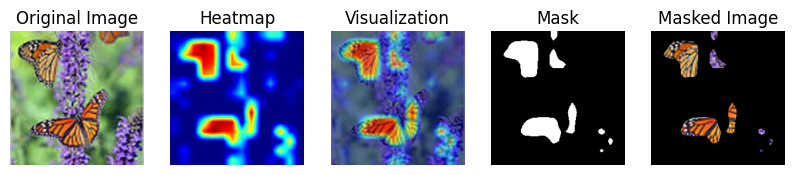

In [45]:
tensor, rgb_img = preprocess_image(dataset[1])  # Using the first image from the dataset for demonstration
heatmap2, visualization2, mask2 = viT_gradcam(tensor, rgb_img, threshold=0.5)
axs = plt.figure(figsize=(10, 10)).subplots(1, 5)
axs = axs.flatten()
axs[0].imshow(rgb_img)
axs[0].set_title("Original Image")
axs[0].axis("off")
axs[1].imshow(heatmap2)
axs[1].set_title("Heatmap")
axs[1].axis("off")
axs[2].imshow(visualization2)
axs[2].set_title("Visualization")
axs[2].axis("off")
axs[3].imshow(mask2, cmap="gray")
axs[3].set_title("Mask")
axs[3].axis("off")
axs[4].imshow(rgb_img * mask2.reshape(224, 224,1))  # Apply the mask to the original image
axs[4].set_title("Masked Image")
axs[4].axis("off")

In [9]:
def vit_reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.permute(0, 3, 1, 2)
    return result

def viT(images, labels, name, path):
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).eval()
    target_layers = [model.encoder.layers[-1].ln_1]
    cam = GradCAM(model=model, 
                target_layers=target_layers, 
                reshape_transform=vit_reshape_transform)
    
    for i in range(images.shape[0]):
        input_tensor, _ = preprocess_image(images[i])
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
        cam_item = GrayscaleCAMItem(grayscale_cam, name[i], labels[i])
        save_dir = Path(path)
        save_dir.mkdir(parents=True, exist_ok=True)
        np.save(save_dir / f"{i}", cam_item)
        if i % 100 == 0:
            print(f"Processed {i}/{images.shape[0]} images")
    

In [ ]:
viT(X_train[:20], y_train[:20], name_train[:20], path="./Heatmap_train/viT")

In [10]:
def long_execution2():
    viT(X_train, y_train, name_train, path="./Heatmap_train/viT")
    viT(X_test, y_test, name_test, path="./Heatmap_test/viT")

Swin Transformer

In [24]:
# 2. Define the Reshape Transform for Swin
def swin_reshape_transform(tensor, height=7, width=7):
    # tensor shape is [1, 49, 1024]
    # We want to reshape it to [1, 7, 7, 1024]
    
    # Use -1 for the channel dimension so it "auto-fills" the 1024
    result = tensor.reshape(tensor.size(0), height, width, -1)
    
    # Now move channels to the front for Grad-CAM: [1, 1024, 7, 7]
    result = result.permute(0, 3, 1, 2)
    return result

def swinT_gradcam(input_tensor, rgb_img, threshold=0.5):
    # 1. Load the pre-trained Swin Transformer
    model = models.swin_b(weights=models.Swin_B_Weights.IMAGENET1K_V1).eval()
    # 3. Select the target layer
    # We target the very last layer of the feature extractor
    target_layers = [model.features[-1]]

    # 4. Initialize Grad-CAM
    cam = GradCAM(model=model, 
                target_layers=target_layers, 
                reshape_transform=swin_reshape_transform)

    # 5. Run the CAM
    # (Assuming input_tensor is already on .cuda())
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)
    mask = np.where(grayscale_cam> threshold, 1, 0)[0]  # Thresholding the CAM for better visualization
    # 5. Overlay and Save
    # We take [0, :] because we only passed one image (batch size 1)
    visualization = show_cam_on_image(rgb_img, grayscale_cam[0, :], use_rgb=True)
    heatmap = cv2.applyColorMap(np.uint8(255 * grayscale_cam[0, :]), cv2.COLORMAP_JET)
    # cam_swint = visualization
    return heatmap[:,:,::-1], visualization, mask
# plt.imshow(visualization)
# plt.show()
# plt.imshow(rgb_img * mask.reshape(224, 224,1))  # Apply the mask to the original image

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

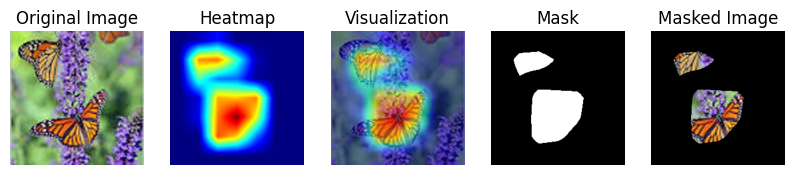

In [46]:
tensor, rgb_img = preprocess_image(dataset[1])  # Using the first image from the dataset for demonstration
heatmap3, visualization3, mask3 = swinT_gradcam(tensor, rgb_img, threshold=0.5)
axs = plt.figure(figsize=(10, 10)).subplots(1, 5)
axs = axs.flatten()
axs[0].imshow(rgb_img)
axs[0].set_title("Original Image")
axs[0].axis("off")
axs[1].imshow(heatmap3)
axs[1].set_title("Heatmap")
axs[1].axis("off")
axs[2].imshow(visualization3)
axs[2].set_title("Visualization")
axs[2].axis("off")
axs[3].imshow(mask3, cmap="gray")
axs[3].set_title("Mask")
axs[3].axis("off")
axs[4].imshow(rgb_img * mask3.reshape(224, 224,1))  # Apply the mask to the original image
axs[4].set_title("Masked Image")
axs[4].axis("off")

In [11]:
def swin_reshape_transform(tensor, height=7, width=7):
    result = tensor.reshape(tensor.size(0), height, width, -1)
    result = result.permute(0, 3, 1, 2)
    return result

def swinT(images, labels, name, path):
    model = models.swin_b(weights=models.Swin_B_Weights.IMAGENET1K_V1).eval()
    target_layers = [model.features[-1]]
    cam = GradCAM(model=model, 
                target_layers=target_layers, 
                reshape_transform=swin_reshape_transform)
    
    for i in range(images.shape[0]):
        input_tensor, _ = preprocess_image(images[i])
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
        cam_item = GrayscaleCAMItem(grayscale_cam, name[i], labels[i])
        save_dir = Path(path)
        save_dir.mkdir(parents=True, exist_ok=True)
        np.save(save_dir / f"{i}", cam_item)
        if i % 100 == 0:
            print(f"Processed {i}/{images.shape[0]} images")

In [ ]:
swinT(X_train[:20], y_train[:20], name_train[:20], path="./Heatmap_train/swinT")

In [12]:
def long_execution3():
    swinT(X_train, y_train, name_train, path="./Heatmap_train/swinT")
    swinT(X_test, y_test, name_test, path="./Heatmap_test/swinT")

In [ ]:

def visualize_gradcam_on_dataset(img, gradcam_function):
    #img = dataset[2] 
    input_tensor, rgb_img = preprocess_image(img)
    heatmap, cam_resnet, mask_resnet = gradcam_function(input_tensor, rgb_img, threshold=0.5)
      # Convert BGR to RGB for correct visualization

    axs = plt.figure(figsize=(15, 15)).subplots(1, 5)
    axs = axs.flatten()
    axs[0].imshow(img)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    axs[1].imshow(heatmap, cmap='jet')
    axs[1].set_title(f"{gradcam_function.__name__}")
    axs[1].axis("off")

    axs[2].imshow(cam_resnet)
    axs[2].set_title("Overlay")
    axs[2].axis("off")

    axs[3].imshow(mask_resnet, cmap='gray')
    axs[3].set_title("Mask")
    axs[3].axis("off")

    axs[4].imshow(rgb_img * mask_resnet.reshape(224, 224, 1))
    axs[4].set_title("Masked Image")
    axs[4].axis("off")
    



In [ ]:
visualize_gradcam_on_dataset(dataset[1], resnet152_gradcam)
visualize_gradcam_on_dataset(dataset[1], viT_gradcam)
visualize_gradcam_on_dataset(dataset[1], swinT_gradcam)

IFCNN 1

In [ ]:
'''---------------------------------------------------------------------------
IFCNN: A General Image Fusion Framework Based on Convolutional Neural Network
----------------------------------------------------------------------------'''
import torch
import math
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


# My Convolution Block
class ConvBlock(nn.Module):
    def __init__(self, inplane, outplane):
        super(ConvBlock, self).__init__()
        self.padding = (1, 1, 1, 1)
        self.conv = nn.Conv2d(inplane, outplane, kernel_size=3, padding=0, stride=1, bias=False)
        self.bn = nn.BatchNorm2d(outplane)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = F.pad(x, self.padding, 'replicate')
        out = self.conv(out)
        out = self.bn(out)
        out = self.relu(out)
        return out

    
class IFCNN(nn.Module):
    def __init__(self, resnet, w0=0.7, w1=0.3):
        super(IFCNN, self).__init__()
        self.w0 = w0
        self.w1 = w1
        self.conv2 = ConvBlock(64, 64)
        self.conv3 = ConvBlock(64, 64)
        self.conv4 = nn.Conv2d(64, 3, kernel_size=1, padding=0, stride=1, bias=True)

        # Initialize parameters for other parameters
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))

        # Initialize conv1 with the pretrained resnet101 and freeze its parameters
        for p in resnet.parameters():
            p.requires_grad = False
        self.conv1 = resnet.conv1
        self.conv1.stride = 1
        self.conv1.padding = (0, 0)
        
    def attention_rec_logic(self, features):
        """
        Implementazione matematica dell'operatore Attention_rec (Eq. 3 e 4) [cite: 270, 273]
        features: lista di 3 tensori [ResNet_feat, ViT_feat, SwinT_feat] provenienti da CONV2
        """
        # Stack dei tensori per facilitare le operazioni di unione/intersezione
        # Dimensione: [3, batch, 64, H, W]
        stacked_feats = torch.stack(features, dim=0)
        
        # Intersezione (Consenso): il valore minimo pixel-per-pixel 
        intersection, _ = torch.min(stacked_feats, dim=0)
        
        # Unione: il valore massimo pixel-per-pixel 
        union, _ = torch.max(stacked_feats, dim=0)
        
        # Formula: w0 * Intersezione + w1 * (Unione - Intersezione) [cite: 273, 275]
        # Nota: Nel paper si cita anche 'Eigen' come metodo di smoothing [cite: 275]
        # Qui simuliamo la logica di fusione dei pesi alpha_i^k [cite: 275]
        f_hat = self.w0 * intersection + self.w1 * (union - intersection)
        
        return f_hat

    def operate(self, operator, tensors):
        out_tensors = []
        for tensor in tensors:
            out_tensor = operator(tensor)
            out_tensors.append(out_tensor)
        return out_tensors

    def tensor_padding(self, tensors, padding=(1, 1, 1, 1), mode='constant', value=0):
        out_tensors = []
        for tensor in tensors:
            out_tensor = F.pad(tensor, padding, mode=mode, value=value)
            out_tensors.append(out_tensor)
        return out_tensors

    def forward(self, *tensors):
        # Feature extraction
        outs = self.tensor_padding(tensors=tensors, padding=(3, 3, 3, 3), mode='replicate')
        outs = self.operate(self.conv1, outs)
        outs = self.operate(self.conv2, outs)
        
        # Feature fusion
        out = self.attention_rec_logic(outs)
        
        # Feature reconstruction
        out = self.conv3(out)
        out = self.conv4(out)
        return out


def myIFCNN(w0=0.7, w1=0.3):
    # pretrained resnet101
    resnet = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
    # our model
    model = IFCNN(resnet, w0=w0, w1=w1)
    return model

In [ ]:
# To DELETE
def normalize(x, v_min, v_max):
    return (x - v_min) / (v_max - v_min)

def IFCNN_cam(rgb_img, cam_resnet, cam_vit, cam_swint, threshold):
    model = myIFCNN(w0=0.7, w1=0.3)
    # model = load_checkpoint_safely(model, 'weights/IFCNN-SUM.pth')
    model.load_state_dict(torch.load('weights/IFCNN-SUM.pth', map_location=torch.device('cpu')))
    model.eval()
    output_cam = model(torch.tensor(cam_resnet, dtype=torch.float32).permute(2, 0, 1).reshape(1, 3, 224, 224), torch.tensor(cam_vit, dtype=torch.float32).permute(2, 0, 1).reshape(1, 3, 224, 224), torch.tensor(cam_swint, dtype=torch.float32).permute(2, 0, 1).reshape(1, 3, 224, 224))
    cam_IFCNN = normalize(output_cam, output_cam.min(), output_cam.max()).reshape(3, 224, 224).detach().numpy().transpose(1, 2, 0)
    # plt.imshow(cam_IFCNN)
    greyscale_cam_IFCNN = np.dot(cam_IFCNN, [0.2989, 0.5870, 0.1140])  # Convert to grayscale using luminosity method
    # visualization = show_cam_on_image(rgb_img, greyscale_cam_IFCNN[0, :], use_rgb=True)
    # mask = np.where(greyscale_cam_IFCNN > 0.5, 1, 0)  # Thresholding the CAM for better visualization
    
    
    # grayscale_cam = cam(input_tensor=input_tensor, targets=None)
    mask = np.where(greyscale_cam_IFCNN> threshold, 1, 0)  # Thresholding the CAM for better visualization
    # 5. Overlay and Save
    # We take [0, :] because we only passed one image (batch size 1)
    visualization = show_cam_on_image(rgb_img, greyscale_cam_IFCNN[ :], use_rgb=True)
    heatmap = cv2.applyColorMap(np.uint8(255 * greyscale_cam_IFCNN[ :]), cv2.COLORMAP_JET)
    # cam_swint = visualization
    return cam_IFCNN, visualization, mask


    # return cam_IFCNN, visualization, mask

In [ ]:
threshold = 0.5
img = dataset[0]
input_tensor, rgb_img = preprocess_image(img)
heatmap1, cam1, mask1 = resnet152_gradcam(input_tensor, rgb_img, threshold)
heatmap2, cam2, mask2 = viT_gradcam(input_tensor, rgb_img, threshold)
heatmap3, cam3, mask3 = swinT_gradcam(input_tensor, rgb_img, threshold)
# heatmap4, cam4, mask4 = IFCNN_cam(rgb_img, heatmap1.copy(), heatmap2.copy(), heatmap3.copy(), threshold)

In [ ]:
axs = plt.figure(figsize=(15, 5)).subplots(2, 5)

axs[0][0].imshow(img)
axs[0][0].set_title("Original Image")
axs[0][0].axis("off")

axs[0][1].imshow(cam1, cmap='jet')
axs[0][1].set_title("resnet152_gradcam")
axs[0][1].axis("off")

axs[0][2].imshow(cam2, cmap='jet')
axs[0][2].set_title("viT_gradcam")
axs[0][2].axis("off")

axs[0][3].imshow(cam3, cmap='jet')
axs[0][3].set_title("swinT_gradcam")
axs[0][3].axis("off")

# axs[0][4].imshow(cam4, cmap='jet')
# axs[0][4].set_title("IFCNN")
# axs[0][4].axis("off")

axs[1][0].imshow(img)
axs[1][0].set_title("Original Image")
axs[1][0].axis("off")

axs[1][1].imshow(img * mask1.reshape(224, 224, 1), cmap='jet')
axs[1][1].set_title("resnet152_gradcam")
axs[1][1].axis("off")

axs[1][2].imshow(img * mask2.reshape(224, 224, 1), cmap='jet')
axs[1][2].set_title("viT_gradcam")
axs[1][2].axis("off")

axs[1][3].imshow(img * mask3.reshape(224, 224, 1), cmap='jet')
axs[1][3].set_title("swinT_gradcam")
axs[1][3].axis("off")

axs[1][4].imshow(img * mask4.reshape(224, 224, 1), cmap='jet')
axs[1][4].set_title("IFCNN")
axs[1][4].axis("off")

IFCNN 2

In [ ]:
'''---------------------------------------------------------------------------
IFCNN: A General Image Fusion Framework Based on Convolutional Neural Network
----------------------------------------------------------------------------'''
import torch
import math
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# My Convolution Block
class ConvBlock(nn.Module):
    def __init__(self, inplane, outplane):
        super(ConvBlock, self).__init__()
        self.padding = (1, 1, 1, 1)
        self.conv = nn.Conv2d(inplane, outplane, kernel_size=3, padding=0, stride=1, bias=False)
        self.bn = nn.BatchNorm2d(outplane)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = F.pad(x, self.padding, 'replicate')
        out = self.conv(out)
        out = self.bn(out)
        out = self.relu(out)
        return out
    
class IFCNN(nn.Module):
    def __init__(self, resnet, w0=0.7, w1=0.3):
        super(IFCNN, self).__init__()
        self.w0 = w0
        self.w1 = w1
        
        self.conv2 = ConvBlock(64, 64)
        
        # CORRECTED: CONV3 must output 128 channels per the diagram
        self.conv3 = ConvBlock(64, 128)
        
        # CORRECTED: CONV4 must accept the 128 channels from CONV3
        self.conv4 = nn.Conv2d(128, 3, kernel_size=1, padding=0, stride=1, bias=True)

        # Initialize parameters for other parameters
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))

        # Initialize conv1 with the pretrained resnet101 and freeze its parameters
        for p in resnet.parameters():
            p.requires_grad = False
        self.conv1 = resnet.conv1
        self.conv1.stride = 1
        self.conv1.padding = (0, 0)
        
    def eigen_smoothing(self, f_hat):
        """
        Implementation of 'Eigen' smoothing (Ref 46: pytorch-grad-cam).
        Uses SVD to extract the first principal component (denoising), 
        and projects it back to the original channel depth.
        """
        b, c, h, w = f_hat.shape
        
        # Reshape to [batch, H*W, channels] for spatial PCA
        reshaped = f_hat.view(b, c, -1).transpose(1, 2)
        
        # Center the activations (Crucial for SVD/PCA accuracy)
        mean = reshaped.mean(dim=1, keepdim=True)
        centered = reshaped - mean
        
        # Perform SVD (U: [b, H*W, c], S: [b, c], Vh: [b, c, c])
        U, S, Vh = torch.linalg.svd(centered, full_matrices=False)
        
        # Rank-1 Reconstruction: Keep ONLY the first principal component (highest variance)
        U_1 = U[:, :, 0]       # [b, H*W]
        S_1 = S[:, 0]          # [b]
        Vh_1 = Vh[:, 0, :]     # [b, c]
        
        # Batch outer product to reconstruct the tensor without the noise
        US_1 = (U_1 * S_1.unsqueeze(1)).unsqueeze(2) # [b, H*W, 1]
        Vh_1_exp = Vh_1.unsqueeze(1)                 # [b, 1, c]
        denoised = torch.bmm(US_1, Vh_1_exp)         # [b, H*W, c]
        
        # Add the mean back and restore spatial dimensions
        denoised = denoised + mean
        smoothed = denoised.transpose(1, 2).view(b, c, h, w)
        
        return smoothed

    def attention_rec_logic(self, features):
        """
        Implementation of the Attention_rec operator (Eq. 3 and 4)
        """
        stacked_feats = torch.stack(features, dim=0)
        
        # CORRECTED: Intersection (Consensus) is MINIMUM, Union (Aggregation) is MAXIMUM
        intersection, _ = torch.min(stacked_feats, dim=0)
        union, _ = torch.max(stacked_feats, dim=0)
        
        # Eq 4 Logic
        f_hat = self.w0 * intersection + self.w1 * (union - intersection)
        
        # Apply Eigen smoothing to minimize noises (Ref 46)
        f_hat = self.eigen_smoothing(f_hat)
        
        return f_hat

    def operate(self, operator, tensors):
        out_tensors = []
        for tensor in tensors:
            out_tensor = operator(tensor)
            out_tensors.append(out_tensor)
        return out_tensors

    def tensor_padding(self, tensors, padding=(1, 1, 1, 1), mode='constant', value=0):
        out_tensors = []
        for tensor in tensors:
            out_tensor = F.pad(tensor, padding, mode=mode, value=value)
            out_tensors.append(out_tensor)
        return out_tensors

    def forward(self, *tensors):
        # Feature extraction
        outs = self.tensor_padding(tensors=tensors, padding=(3, 3, 3, 3), mode='replicate')
        outs = self.operate(self.conv1, outs)
        outs = self.operate(self.conv2, outs)
        
        # Feature fusion (Attention-Selection Mechanism)
        out = self.attention_rec_logic(outs)
        
        # Feature reconstruction
        out = self.conv3(out)
        out = self.conv4(out)
        return out

def myIFCNN(w0=0.7, w1=0.3):
    # pretrained resnet101
    resnet = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
    # our model
    model = IFCNN(resnet, w0=w0, w1=w1)
    return model

In [ ]:
def load_checkpoint_safely(model, checkpoint_path):
    # 1. Load the pre-trained checkpoint
    pretrained_dict = torch.load(checkpoint_path, map_location='cpu')
    
    # Check if the checkpoint is nested (often saved under a 'state_dict' or 'model' key)
    if 'state_dict' in pretrained_dict:
        pretrained_dict = pretrained_dict['state_dict']
        
    # 2. Get the current model's state dictionary
    model_dict = model.state_dict()

    # 3. Filter out the mismatched keys (keep only keys that exist in both AND have the same shape)
    filtered_dict = {
        k: v for k, v in pretrained_dict.items() 
        if k in model_dict and v.shape == model_dict[k].shape
    }

    # Print what we are skipping so you can verify
    skipped_keys = set(pretrained_dict.keys()) - set(filtered_dict.keys())
    print(f"Skipping {len(skipped_keys)} mismatched layers: {skipped_keys}")

    # 4. Overwrite the matching layers in the current model's dict
    model_dict.update(filtered_dict) 

    # 5. Load the updated dictionary back into the model
    # strict=True is fine here because model_dict has exactly the keys the model expects
    model.load_state_dict(model_dict)
    
    print("Checkpoint loaded successfully!")
    return model

# --- How to use it ---
# my_model = myIFCNN()
# my_model = load_checkpoint_safely(my_model, 'path_to_original_ifcnn_weights.pth')

In [ ]:
# ==========================================
# HOW TO USE IT IN YOUR SCRIPT:
# ==========================================

# 1. Initialize and load the model ONCE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fusion_model = myIFCNN(w0=0.7, w1=0.3)
fusion_model = load_checkpoint_safely(fusion_model, 'weights/IFCNN-SUM.pth')
fusion_model = fusion_model.to(device)

# 2. Run inference in a loop (fast)
# for image, cams in your_dataset:
#     cam_out, vis, mask, key_areas = run_IFCNN_cam(
#         model=fusion_model, 
#         rgb_img=image, 
#         cam_resnet=cams[0], 
#         cam_vit=cams[1], 
#         cam_swint=cams[2], 
#         threshold=0.5, 
#         device=device
#     )

In [ ]:
import torch
import numpy as np
import cv2
# Assuming show_cam_on_image is imported from pytorch_grad_cam.utils.image

def normalize(x, v_min, v_max):
    return (x - v_min) / (v_max - v_min + 1e-8) # Added 1e-8 to prevent division by zero

def run_IFCNN_cam(model, rgb_img, cam_resnet, cam_vit, cam_swint, threshold, device='cpu'):
    """
    Pass the pre-loaded model to this function to avoid reloading it every time.
    """
    model.eval()
    
    # Prepare tensors and move to device (unsqueeze(0) adds the batch dimension)
    t_resnet = torch.tensor(cam_resnet, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)
    t_vit = torch.tensor(cam_vit, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)
    t_swint = torch.tensor(cam_swint, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)
    
    # Disable gradient tracking for inference
    with torch.no_grad():
        output_cam = model(t_resnet, t_vit, t_swint)
    
    # Move back to CPU for numpy operations
    output_cam = output_cam.cpu()
    plt.imshow(output_cam.squeeze(0).permute(1, 2, 0).numpy(), cmap='jet')
    # Normalize and format to HxWxC
    cam_IFCNN = normalize(output_cam, output_cam.min(), output_cam.max())
    cam_IFCNN = cam_IFCNN.squeeze(0).numpy().transpose(1, 2, 0) # squeeze(0) removes the batch dim
    
    # Convert to grayscale to evaluate neuron importance weights (Algorithm 1)
    greyscale_cam_IFCNN = np.dot(cam_IFCNN, [0.2989, 0.5870, 0.1140])
    
    # 1. Extract important regions (Mask generation based on threshold w_t)
    mask = np.where(greyscale_cam_IFCNN > threshold, 1, 0)
    
    # 2. Bitwise operation with the original image (Algorithm 1 final step)
    # We expand the mask to 3 channels so it can multiply against the RGB image
    mask_3d = np.expand_dims(mask, axis=-1)
    extracted_key_areas = rgb_img * mask_3d
    
    # Visualizations
    visualization = show_cam_on_image(rgb_img, greyscale_cam_IFCNN, use_rgb=True)
    heatmap = cv2.applyColorMap(np.uint8(255 * greyscale_cam_IFCNN), cv2.COLORMAP_JET)
    
    return cam_IFCNN, visualization, mask, extracted_key_areas



In [ ]:
threshold = 0.5
img = dataset[0]
input_tensor, rgb_img = preprocess_image(img)
heatmap1, cam1, mask1 = resnet152_gradcam(input_tensor, rgb_img, threshold)
heatmap2, cam2, mask2 = viT_gradcam(input_tensor, rgb_img, threshold)
heatmap3, cam3, mask3 = swinT_gradcam(input_tensor, rgb_img, threshold)
cam_IFCNN, visualization, mask, extracted_key_areas = run_IFCNN_cam(fusion_model, rgb_img, heatmap1.copy(), heatmap2.copy(), heatmap3.copy(), 0.3, device=device)

In [ ]:
cam_IFCNN, visualization, mask, extracted_key_areas = run_IFCNN_cam(fusion_model, rgb_img, heatmap1.copy(), heatmap2.copy(), heatmap3.copy(), 0.7, device=device)

In [13]:
# ---------------------------------------------------------------------------
# IFCNN — Attention-Selection Mechanism (fixed)
# Correzioni rispetto alla versione originale:
#   1. min/max invertiti in attention_rec_logic
#   2. eigen_smoothing riscritta per operare su un singolo sample [C, H, W]
#   3. forward gestisce i 3 CAM come lista e applica tied weights correttamente
# ---------------------------------------------------------------------------

import torch
import math
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


class ConvBlock(nn.Module):
    def __init__(self, inplane, outplane):
        super().__init__()
        self.padding = (1, 1, 1, 1)
        self.conv = nn.Conv2d(inplane, outplane, kernel_size=3, padding=0,
                              stride=1, bias=False)
        self.bn   = nn.BatchNorm2d(outplane)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = F.pad(x, self.padding, 'replicate')
        out = self.conv(out)
        out = self.bn(out)
        out = self.relu(out)
        return out


class IFCNN(nn.Module):
    def __init__(self, resnet, w0=0.7, w1=0.3):
        super().__init__()
        self.w0 = w0
        self.w1 = w1

        # CONV2: 64->64  (tied weights tra i 3 input, cioè stesso layer riusato)
        self.conv2 = ConvBlock(64, 64)

        # CONV3: 64->128  (dal diagramma Fig.3: Feature Maps 64 -> 128)
        self.conv3 = ConvBlock(64, 64)

        # CONV4: 128->3   (ricostruzione a 3 canali RGB)
        self.conv4 = nn.Conv2d(64, 3, kernel_size=1, padding=0,
                               stride=1, bias=True)

        # Init pesi conv learnable
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2.0 / n))

        # CONV1: prende conv1 di ResNet pretrained, stride=1, no padding
        for p in resnet.parameters():
            p.requires_grad = False
        self.conv1 = resnet.conv1
        self.conv1.stride  = (1, 1)
        self.conv1.padding = (0, 0)

    # ------------------------------------------------------------------
    # BUG 2 FIX: eigen_smoothing opera su un singolo sample [C, H, W]
    # (non su un batch). La SVD estrae la prima componente principale
    # nello spazio dei canali per ogni posizione spaziale.
    # ------------------------------------------------------------------
    def eigen_smoothing(self, f_hat: torch.Tensor) -> torch.Tensor:
        """
        Smoothing basato sulla prima componente principale (Ref 46, Eigen-CAM).
        Input:  f_hat  [B, C, H, W]
        Output: smoothed  [B, C, H, W]
        """
        B, C, H, W = f_hat.shape
        smoothed_list = []

        for b in range(B):
            # [C, H*W]  →  [H*W, C]
            feat = f_hat[b].view(C, -1).T          # [H*W, C]

            # Centratura
            mean   = feat.mean(dim=0, keepdim=True) # [1, C]
            centered = feat - mean                   # [H*W, C]

            # SVD: U [H*W, k], S [k], Vh [k, C]  dove k = min(H*W, C)
            U, S, Vh = torch.linalg.svd(centered, full_matrices=False)

            # Ricostruzione rank-1 (solo il primo componente)
            # U[:,0] * S[0] riproiettato su Vh[0,:]
            rank1 = (U[:, 0:1] * S[0]) @ Vh[0:1, :]  # [H*W, C]

            # Riaggiungo la media e riporto a [C, H, W]
            denoised = (rank1 + mean).T.view(C, H, W)
            smoothed_list.append(denoised)

        return torch.stack(smoothed_list, dim=0)  # [B, C, H, W]

    # BUG 1 FIX: intersection = min, union = max (Eq. 4)
    # ------------------------------------------------------------------
    def attention_rec_logic(self, features: list) -> torch.Tensor:
        """
        Eq. 3-4 del paper:
            ∩  = min tra i modelli  (consenso: pixel evidenziati da TUTTI)
            ∪  = max tra i modelli  (aggregazione: pixel evidenziati da ALMENO uno)
            f̂  = w0 * ∩  +  w1 * (∪ - ∩)
        """
        stacked = torch.stack(features, dim=0)   # [N_models, B, C, H, W]
 
        # BUG 1 era qui: erano invertiti
        intersection, _ = torch.min(stacked, dim=0)   # ∩
        union,        _ = torch.max(stacked, dim=0)   # ∪
 
        f_hat = self.w0 * intersection + self.w1 * (union - intersection)
 
        # Eigen-smoothing per ridurre il rumore
        f_hat = self.eigen_smoothing(f_hat)
 
        return f_hat
 
    # ------------------------------------------------------------------
    # BUG 3 FIX: forward gestisce lista di tensori e riusa correttamente
    # gli stessi layer (CONV1, CONV2) come tied weights per ogni CAM.
    # ------------------------------------------------------------------
    def forward(self, *tensors):
        """
        tensors: N immagini/CAM in input (nel paper N=3: ResNet, ViT, Swin-T).
        Ogni tensore ha shape [B, 3, H, W].
        """
        # --- Feature Extraction (CONV1 + CONV2, tied weights) ---
        outs = []
        for t in tensors:
            # Padding replicativo prima di CONV1 (kernel 7×7 → pad 3)
            x = F.pad(t, (3, 3, 3, 3), mode='replicate')
            x = self.conv1(x)     # [B, 64, H, W]
            x = self.conv2(x)     # [B, 64, H, W]
            outs.append(x)
 
        # --- Feature Fusion (Attention-Selection) ---
        fused = self.attention_rec_logic(outs)   # [B, 64, H, W]
 
        # --- Feature Reconstruction (CONV3 + CONV4) ---
        out = self.conv3(fused)   # [B, 128, H, W]
        out = self.conv4(out)     # [B,   3, H, W]
        return out
 
 
def myIFCNN(w0=0.7, w1=0.3):
    resnet = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
    model  = IFCNN(resnet, w0=w0, w1=w1)
    return model
 


In [39]:
# --- Quick sanity check ---
model = myIFCNN(w0=0.7, w1=0.3)
model.load_state_dict(torch.load('weights/IFCNN-SUM.pth', map_location=torch.device('cpu')))
model.eval()

# Simula 3 CAM in input (ResNet, ViT, Swin-T), batch=2, 224×224
# cam1 = torch.randn(2, 3, 224, 224)
# cam2 = torch.randn(2, 3, 224, 224)
# cam3 = torch.randn(2, 3, 224, 224)

# 2. Cast to float32
# t_heat1 = torch.from_numpy(heatmap1.copy()).float()
# t_heat2 = torch.from_numpy(heatmap2.copy()).float()
# t_heat3 = torch.from_numpy(heatmap3.copy()).float()

t_resnet = torch.tensor(heatmap1.copy(), dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) 
t_vit = torch.tensor(heatmap2.copy(), dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
t_swint = torch.tensor(heatmap3.copy(), dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) 

# 3. (Optional but likely needed) Ensure the shape is [Batch, Channels, Height, Width]
# If your heatmaps are [Height, Width] or [Height, Width, Channels], 
# you will need to unsqueeze or permute them here before passing them to the model.

with torch.no_grad():
    out = model(t_resnet, t_vit, t_swint)
# with torch.no_grad():
#     out = model(heatmap1.copy(), heatmap2.copy(), heatmap3.copy())

print(f"Input shapes : {t_resnet.shape} × 3")
print(f"Output shape : {out.shape}")   # atteso: [2, 3, 224, 224]
print("OK — nessun errore di shape.")

Input shapes : torch.Size([1, 3, 224, 224]) × 3
Output shape : torch.Size([1, 3, 224, 224])
OK — nessun errore di shape.


In [14]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [77]:
def show_ifcnn_heatmap(
    original_img, #: torch.Tensor,   # [3, H, W] float in [0,1]
    ifcnn_output: torch.Tensor,   # [B, 3, H, W] output grezzo di IFCNN
    sample_idx: int = 0,
    threshold: float = 0.4,
    alpha: float = 0.5,
    colormap: str = 'jet',
):
    # 1. Prendi il sample e collassa i 3 canali in uno scalare per pixel
    cam = ifcnn_output[sample_idx]           # [3, H, W]
    # plt.imshow(cam.permute(1, 2, 0).detach().cpu().numpy())
    cam_gray = cam.mean(dim=0)                  # [H, W]

    # 2. Normalizza in [0, 1]
    cam_gray = cam_gray - cam_gray.min()
    cam_gray = cam_gray / (cam_gray.max() + 1e-8)
    cam_np = cam_gray.detach().cpu().numpy()    # [H, W]
    # plt.imshow(cam_np, cmap=colormap)
    # 3. Applica colormap → immagine RGB
    heatmap = cm.get_cmap(colormap)(cam_np)[:, :, :3]  # [H, W, 3]

    # 4. Overlay sull'immagine originale
    img_np = original_img #.permute(1, 2, 0).detach().cpu().numpy()
    overlay = (1 - alpha) * img_np + alpha * heatmap

    # 5. Maschera binaria (dove la CAM supera la soglia)
    mask = (cam_np >= threshold).astype(np.float32)
    masked_img = img_np * mask[:, :, np.newaxis]

    # 6. Plot (single original image in the first column)
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(4, 4)

    # First column: one single original image spanning all rows
    ax0 = fig.add_subplot(gs[:, 0])
    ax0.imshow(img_np.clip(0, 1))
    ax0.set_title("Originale")
    ax0.axis("off")

    # Row 1: ResNet
    ax = fig.add_subplot(gs[0, 1]); ax.imshow(heatmap1); ax.set_title("resnet152_gradcam"); ax.axis("off")
    ax = fig.add_subplot(gs[0, 2]); ax.imshow(visualization1); ax.set_title("Overlay"); ax.axis("off")
    ax = fig.add_subplot(gs[0, 3]); ax.imshow(rgb_img * mask1.reshape(224, 224, 1)); ax.set_title("Key areas (thr=0.5)"); ax.axis("off")

    # Row 2: ViT
    ax = fig.add_subplot(gs[1, 1]); ax.imshow(heatmap2); ax.set_title("viT_gradcam"); ax.axis("off")
    ax = fig.add_subplot(gs[1, 2]); ax.imshow(visualization2); ax.set_title("Overlay"); ax.axis("off")
    ax = fig.add_subplot(gs[1, 3]); ax.imshow(rgb_img * mask2.reshape(224, 224, 1)); ax.set_title("Key areas (thr=0.5)"); ax.axis("off")

    # Row 3: SwinT
    ax = fig.add_subplot(gs[2, 1]); ax.imshow(heatmap3); ax.set_title("swinT_gradcam"); ax.axis("off")
    ax = fig.add_subplot(gs[2, 2]); ax.imshow(visualization3); ax.set_title("Overlay"); ax.axis("off")
    ax = fig.add_subplot(gs[2, 3]); ax.imshow(rgb_img * mask3.reshape(224, 224, 1)); ax.set_title("Key areas (thr=0.5)"); ax.axis("off")

    # Row 4: IFCNN
    ax = fig.add_subplot(gs[3, 1]); ax.imshow(cam_np, cmap=colormap); ax.set_title("IFCNN_gradcam"); ax.axis("off")
    ax = fig.add_subplot(gs[3, 2]); ax.imshow(overlay.clip(0, 1)); ax.set_title("Overlay"); ax.axis("off")
    ax = fig.add_subplot(gs[3, 3]); ax.imshow(masked_img.clip(0, 1)); ax.set_title(f"Key areas (thr={threshold})"); ax.axis("off")

    plt.tight_layout()
    plt.show()


C:\Users\valer\AppData\Local\Temp\ipykernel_16872\482250642.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap = cm.get_cmap(colormap)(cam_np)[:, :, :3]  # [H, W, 3]


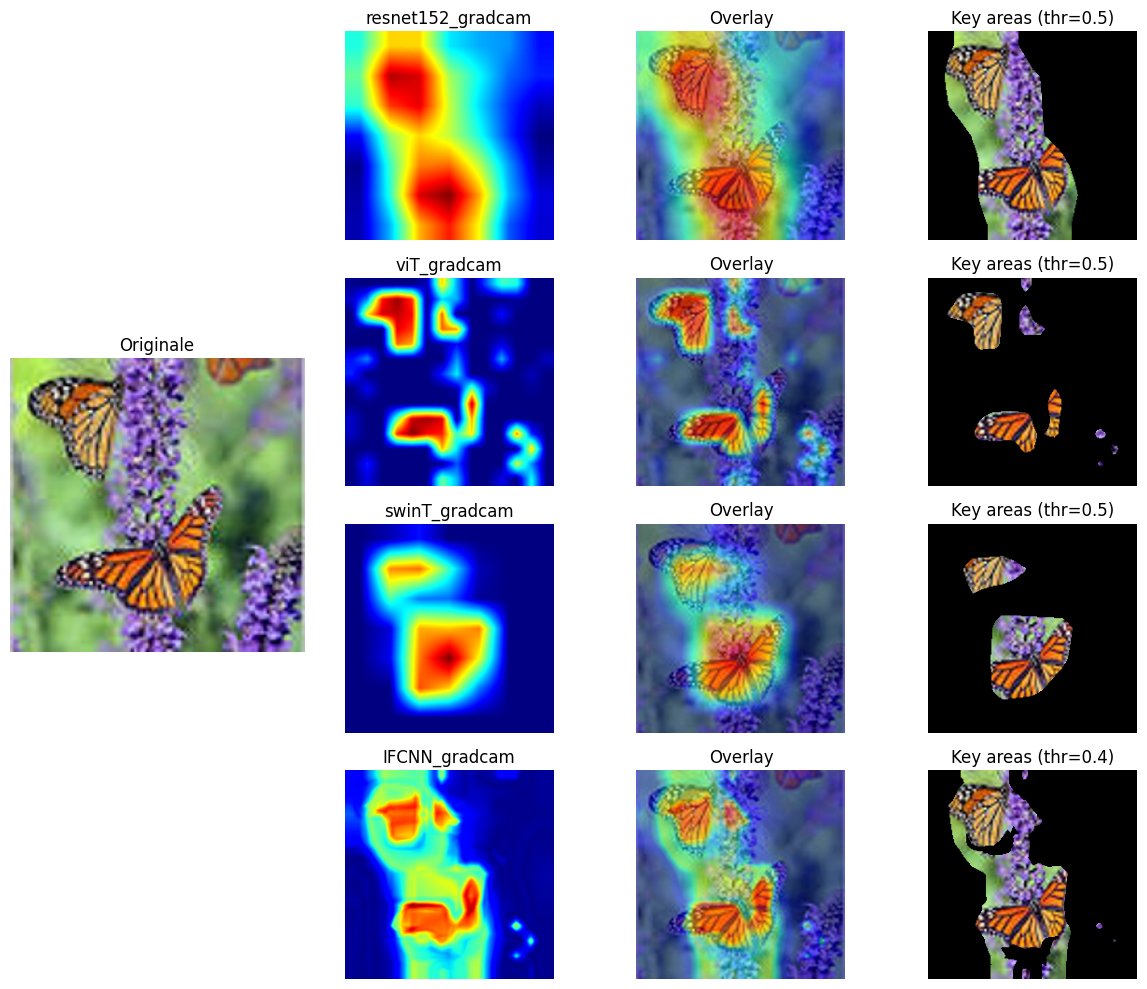

In [78]:
# with torch.no_grad():
#     rec_cam = model(t_resnet, t_vit, t_swint)   # [B, 3, H, W]
# print(f"IFCNN output shape: {rec_cam.shape}")  # atteso: [1, 3, 224, 224]

show_ifcnn_heatmap(rgb_img, out, sample_idx=0)

In [15]:
def show_ifcnn_heatmap(ifcnn_output):
    cam = ifcnn_output[0]
    cam_gray = cam.mean(dim=0)
    cam_gray = cam_gray - cam_gray.min()
    cam_gray = cam_gray / (cam_gray.max() + 1e-8)
    cam_np = cam_gray.detach().cpu().numpy()
    return cam_np

# def from_greyscale_to_heatmap_rgb(cam_gray):
#    return cv2.applyColorMap(np.uint8(255 * cam_gray), cv2.COLORMAP_JET)

# def upload_from_memory():
#     maps = ["resnet", "swinT", "viT"]
#     greyscale_heatmap = []

#     for m in maps:
#         load_dir = Path(f"./Heatmap_train/{m}")
#         npy_files = sorted(load_dir.glob("*.npy"))

#         cam_stack = []
#         for p in npy_files:
#             cam_item = np.load(p, allow_pickle=True).item()
#             cam_stack.append(cam_item)

#         greyscale_heatmap.append(cam_stack)

#     return greyscale_heatmap

def ifcnn_gradcam():
    model = myIFCNN(w0=0.7, w1=0.3)
    model.load_state_dict(torch.load('weights/IFCNN-SUM.pth', map_location=torch.device('cpu')))
    model.eval()
    
    for a in ["train", "test"]:
        resnet_files = sorted(Path(f"./Heatmap_{a}/resnet").glob("*.npy"))
        swin_files = sorted(Path(f"./Heatmap_{a}/swinT").glob("*.npy"))
        vit_files = sorted(Path(f"./Heatmap_{a}/viT").glob("*.npy"))

        for j in range(len(resnet_files)):
            item1 = np.load(resnet_files[j], allow_pickle=True).item()
            item2 = np.load(swin_files[j], allow_pickle=True).item()
            item3 = np.load(vit_files[j], allow_pickle=True).item()
            
            t_resnet = torch.tensor(item1.to_heatmap().copy(), dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) 
            t_vit = torch.tensor(item2.to_heatmap().copy(), dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
            t_swint = torch.tensor(item3.to_heatmap().copy(), dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) 
            
            with torch.no_grad():
                out = model(t_resnet, t_vit, t_swint)
            greyscale_cam_IFCNN = show_ifcnn_heatmap(out)
            
            img_path = Path("./Dataset") / item1.label / item1.name
            original_img = Image.open(img_path).convert("RGB").resize(target_size) 
            
            cam_item = GrayscaleCAMItem(greyscale_cam_IFCNN, item1.name, item1.label, original_img)
            save_dir = Path(f"./Heatmap_{a}/resnet+swinT+viT")
            save_dir.mkdir(parents=True, exist_ok=True)
            np.save(save_dir / f"{j}", cam_item)
            if j % 100 == 0:
                print(f"Processed {j}/{len(resnet_files)} images")
            
            
        # axs = plt.figure(figsize=(15, 5)).subplots(2, 4)
        # axs = axs.flatten()
        # axs[0].imshow(item1.to_heatmap())
        # axs[0].set_title("resnet152_gradcam")
        # axs[0].axis("off")
        # axs[1].imshow(item2.to_heatmap())
        # axs[1].set_title("swinT_gradcam")
        # axs[1].axis("off")
        # axs[2].imshow(item3.to_heatmap())
        # axs[2].set_title("viT_gradcam")
        # axs[2].axis("off")
        # axs[3].imshow(greyscale_cam_IFCNN, cmap='jet')
        # axs[3].set_title("IFCNN")
        # axs[3].axis("off")
        # axs[4].imshow(original_img)
        # axs[4].set_title("Original Image")
        # axs[4].axis("off")
        # axs[5].imshow(cam_item.to_mask(), cmap='gray')
        # axs[5].set_title("IFCNN Mask")
        # axs[5].axis("off")
        # axs[6].imshow(cam_item.to_applied_mask(threshold=0.4))
        # axs[6].set_title("IFCNN Applied Mask")
        # axs[6].axis("off")
        
        # plt.show()

In [ ]:
ifcnn_gradcam()

In [ ]:
# out_tensor = out.squeeze(0).detach().cpu()

# # 2. Handle the channels to make it viewable
# if out_tensor.shape[0] > 3:
#     # If it's a deep feature map (e.g., 64 channels), average them into a single 2D heatmap
#     vis_image = out_tensor.mean(dim=0).numpy()
#     cmap = 'viridis' # Great colormap for heatmaps
# elif out_tensor.shape[0] == 3:
#     # If it's an RGB image, permute back to [Height, Width, Channels]
#     vis_image = out_tensor.permute(1, 2, 0).numpy()
#     # Normalize to [0, 1] for matplotlib if necessary
#     vis_image = (vis_image - vis_image.min()) / (vis_image.max() - vis_image.min())
#     cmap = "jet"
# else: # If it's 1 channel (grayscale)
#     vis_image = out_tensor.squeeze(0).numpy()
#     cmap = 'gray'

# # 3. Plot the image
# plt.figure(figsize=(8, 8))
# plt.imshow(vis_image, cmap=cmap)
# if cmap == 'viridis':
#     plt.colorbar(label='Activation Intensity')
# plt.title(f"Model Output (Shape: {out.shape})")
# plt.axis('off')
# plt.show()

In [ ]:
# axs = plt.figure(figsize=(15, 15)).subplots(1, 5)
# axs = axs.flatten()
# axs[0].imshow(img)
# axs[0].set_title("Original Image")
# axs[0].axis("off")

# axs[1].imshow(cam1, cmap='jet')
# axs[1].set_title("resnet152_gradcam")
# axs[1].axis("off")

# axs[2].imshow(cam2, cmap='jet')
# axs[2].set_title("viT_gradcam")
# axs[2].axis("off")

# axs[3].imshow(cam3, cmap='jet')
# axs[3].set_title("swinT_gradcam")
# axs[3].axis("off")

# axs[4].imshow(visualization, cmap='jet')
# axs[4].set_title("IFCNN")
# axs[4].axis("off")

In [ ]:
# import cv2
# import numpy as np

# def reverse_heatmap(heatmap, colormap=cv2.COLORMAP_JET):
#     # 1. Generate the reference LUT (0 to 255)
#     ref_vals = np.arange(256, dtype=np.uint8).reshape(256, 1)
#     lut = cv2.applyColorMap(ref_vals, colormap) # Shape: (256, 1, 3)

#     # 2. Reshape for broadcasting
#     # Heatmap: (H, W, 3) -> (H, W, 1, 3)
#     # LUT: (256, 1, 3) -> (1, 1, 256, 3)
#     h_img = heatmap.astype(np.float32)[:, :, np.newaxis, :]
#     h_lut = lut.astype(np.float32).reshape(1, 1, 256, 3)

#     # 3. Calculate Squared Euclidean Distance (Faster than np.linalg.norm)
#     # (R1-R2)^2 + (G1-G2)^2 + (B1-B2)^2
#     diff = h_img - h_lut
#     dist_sq = np.sum(diff**2, axis=3)

#     # 4. The index of the minimum distance is the original value
#     grayscale = np.argmin(dist_sq, axis=2)
    
#     return grayscale.astype(np.uint8)

# # Assuming your heatmap was created from grayscale_cam[0, :]
# recovered = reverse_heatmap(cam_IFCNN)
# mask4 = np.where(recovered > 128, 1, 0)

In [ ]:
# import numpy as np

# def extract_importance_mask(img_rgb, threshold=0.55):
#     """
#     img_rgb: np.ndarray of shape (224, 224, 3)
#     threshold: float between 0 and 1
#     """
#     # Normalize to 0-1 if it's currently 0-255
#     if img_rgb.max() > 1.0:
#         img_rgb = img_rgb / 255.0
        
#     # Isolate Red channel and subtract average of others to find "pure" heat
#     # Importance = R - (G + B) / 2
#     importance_map = img_rgb[:, :, 0] - (img_rgb[:, :, 1] + img_rgb[:, :, 2]) / 2
    
#     # Normalize importance map to [0, 1]
#     importance_map = (importance_map - importance_map.min()) / (importance_map.max() - importance_map.min() + 1e-8)
    
#     # Create binary mask
#     mask = (importance_map > threshold).astype(np.uint8)
#     return mask

SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Assuming your data is loaded into the following variables:
# X_train, X_test (Image arrays)
# y_train, y_test (Labels: 0 to 4)

def train_image_svm(X_train, y_train, X_test, y_test):
    # 1. Flatten the images
    # Reshape from (num_samples, height, width, channels) to (num_samples, features)
    num_train_samples = X_train.shape[0]
    num_test_samples = X_test.shape[0]
    
    X_train_flat = X_train.reshape(num_train_samples, -1)
    X_test_flat = X_test.reshape(num_test_samples, -1)
    
    # 2. Scale the data
    # SVMs are highly sensitive to feature scaling; this centers around 0 with a variance of 1.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled = scaler.transform(X_test_flat)
    
    # 3. Initialize and train the SVM
    # The default kernel is 'rbf'. For 5 classes, sklearn automatically uses One-vs-One (OvO).
    print("Training SVM... this might take a while depending on dataset size.")
    svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    
    # 4. Predict and evaluate
    y_pred = svm_model.predict(X_test_scaled)
    
    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    return svm_model, scaler

# Example usage:
# model, fitted_scaler = train_image_svm(X_train, y_train, X_test, y_test)

In [ ]:
files = sorted(Path("./Heatmap_train/resnet+swinT+viT").glob("*.npy"))
img = []
labels = []

for j in range(len(files)):
    item1 = np.load(files[j], allow_pickle=True).item()
    img.append(item1.to_applied_mask(threshold=0.4))  # Assuming each item has a method to get the applied mask
    labels.append(item1.label)  # Assuming each item has a 'label' key

xt, x_t, yt, y_t = train_test_split(
    img, labels, test_size=0.2, random_state=42
)

train_image_svm(np.array(xt), np.array(yt), np.array(x_t), np.array(y_t))

In [16]:
from concurrent.futures import ThreadPoolExecutor

def run_all_models():
    with ThreadPoolExecutor(max_workers=3) as executor:
        futures = [
            executor.submit(long_execution1),
            executor.submit(long_execution2),
            executor.submit(long_execution3),
        ]
        for future in futures:
            future.result()

run_all_models()
ifcnn_gradcam()

Processed 0/3559 images
Processed 0/3559 images
Processed 0/3559 images
Processed 100/3559 images
Processed 100/3559 images
Processed 200/3559 images
Processed 100/3559 images
Processed 300/3559 images
Processed 200/3559 images
Processed 400/3559 images
Processed 200/3559 images
Processed 300/3559 images
Processed 500/3559 images
Processed 300/3559 images
Processed 600/3559 images
Processed 400/3559 images
Processed 700/3559 images
Processed 800/3559 images
Processed 400/3559 images
Processed 500/3559 images
Processed 900/3559 images
Processed 600/3559 images
Processed 1000/3559 images
Processed 500/3559 images
Processed 1100/3559 images
Processed 700/3559 images
Processed 1200/3559 images
Processed 600/3559 images
Processed 1300/3559 images
Processed 800/3559 images
Processed 1400/3559 images
Processed 700/3559 images
Processed 1500/3559 images
Processed 900/3559 images
Processed 1600/3559 images
Processed 800/3559 images
Processed 1000/3559 images
Processed 1700/3559 images
Processed